In [ ]:
import pandas as pd

# Load dataset with encoding fix
malw = pd.read_csv("malware_dataset.csv", encoding="latin1")

# Display basic info
print("Dataset shape:", malw.shape)
print("\nColumn names:\n", malw.columns.tolist())
print("\nData types:\n", malw.dtypes)
print("\nPreview:\n")
malw.head()

Shape (rows, columns): (100000, 35)


,hash,millisecond,classification,state,usage_counter,prio,static_prio,normal_prio,policy,vm_pgoff,...,nivcsw,min_flt,maj_flt,fs_excl_counter,lock,utime,stime,gtime,cgtime,signal_nvcsw
0,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,0,malware,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0
1,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,1,malware,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0
2,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,2,malware,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0
3,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,3,malware,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0
4,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,4,malware,0,0,3069378560,14274,0,0,0,...,0,0,120,0,3204448256,380690,4,0,0,0


hash                 object
millisecond           int64
classification       object
state                 int64
usage_counter         int64
prio                  int64
static_prio           int64
normal_prio           int64
policy                int64
vm_pgoff              int64
vm_truncate_count     int64
task_size             int64
cached_hole_size      int64
free_area_cache       int64
mm_users              int64
map_count             int64
hiwater_rss           int64
total_vm              int64
shared_vm             int64
exec_vm               int64
reserved_vm           int64
nr_ptes               int64
end_data              int64
last_interval         int64
nvcsw                 int64
nivcsw                int64
min_flt               int64
maj_flt               int64
fs_excl_counter       int64
lock                  int64
utime                 int64
stime                 int64
gtime                 int64
cgtime                int64
signal_nvcsw          int64
dtype: object

In [2]:
#Check duplicates and missing values
print("Number of duplicate rows:", malw.duplicated().sum())

print("\nMissing values per column (top 10):")
display(malw.isna().sum().sort_values(ascending=False).head(10))


Number of duplicate rows: 0

Missing values per column (top 10):


hash             0
min_flt          0
reserved_vm      0
nr_ptes          0
end_data         0
last_interval    0
nvcsw            0
nivcsw           0
maj_flt          0
shared_vm        0
dtype: int64

In [3]:
#Map the label and select features

#Map 'classification' values to numbers: benign=0, malware=1
label_map = {"benign": 0, "malware": 1}
y_m = malw["classification"].map(label_map)

#check if mapping worked
print("Unique label values:", y_m.unique())

#Drop unwant columns from features
# drop 'classification' is the label, and 'hash' is just an ID
X_m = malw.drop(columns=["classification", "hash"])

print("\nFeatures shape:", X_m.shape)
print("Label shape:", y_m.shape)

# preview first few feature rows
display(X_m.head())


Unique label values: [1 0]

Features shape: (100000, 33)
Label shape: (100000,)


,millisecond,state,usage_counter,prio,static_prio,normal_prio,policy,vm_pgoff,vm_truncate_count,task_size,...,nivcsw,min_flt,maj_flt,fs_excl_counter,lock,utime,stime,gtime,cgtime,signal_nvcsw
0,0,0,0,3069378560,14274,0,0,0,13173,0,...,0,0,120,0,3204448256,380690,4,0,0,0
1,1,0,0,3069378560,14274,0,0,0,13173,0,...,0,0,120,0,3204448256,380690,4,0,0,0
2,2,0,0,3069378560,14274,0,0,0,13173,0,...,0,0,120,0,3204448256,380690,4,0,0,0
3,3,0,0,3069378560,14274,0,0,0,13173,0,...,0,0,120,0,3204448256,380690,4,0,0,0
4,4,0,0,3069378560,14274,0,0,0,13173,0,...,0,0,120,0,3204448256,380690,4,0,0,0


In [4]:
#Fill any missing numeric values with median
import pandas as pd

num_cols = [c for c in X_m.columns if pd.api.types.is_numeric_dtype(X_m[c])]

for c in num_cols:
    if X_m[c].isna().any():
        X_m[c] = X_m[c].fillna(X_m[c].median())

print("Checked all numeric columns")


Checked all numeric columns


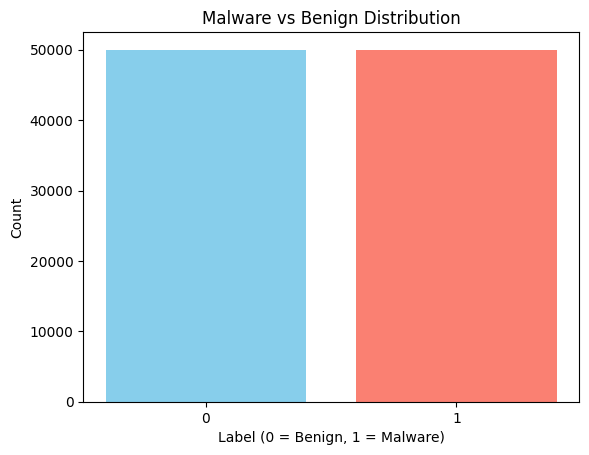

Counts:
 classification
0    50000
1    50000
Name: count, dtype: int64


In [5]:
#Check how many malware vs benign samples
import matplotlib.pyplot as plt

counts = y_m.value_counts().sort_index()

plt.bar(counts.index, counts.values, color=["skyblue", "salmon"])
plt.title("Malware vs Benign Distribution")
plt.xlabel("Label (0 = Benign, 1 = Malware)")
plt.ylabel("Count")
plt.xticks([0, 1])
plt.show()

print("Counts:\n", counts)


In [6]:
#Split the dataset into train, validation, and test sets
from sklearn.model_selection import train_test_split

#Split 80% train, 20% temporary
X_train_m, X_temp_m, y_train_m, y_temp_m = train_test_split(
    X_m, y_m, test_size=0.2, random_state=42, stratify=y_m
)

#Split that 20% equally into validation and test
X_valid_m, X_test_m, y_valid_m, y_test_m = train_test_split(
    X_temp_m, y_temp_m, test_size=0.5, random_state=42, stratify=y_temp_m
)

print("Train:", X_train_m.shape, y_train_m.shape)
print("Valid:", X_valid_m.shape, y_valid_m.shape)
print("Test :", X_test_m.shape,  y_test_m.shape)


Train: (80000, 33) (80000,)
Valid: (10000, 33) (10000,)
Test : (10000, 33) (10000,)


In [7]:
#Standardize numeric features
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

# identify numeric columns
num_cols = [c for c in X_train_m.columns if pd.api.types.is_numeric_dtype(X_train_m[c])]

# fit on training data only
X_train_scaled = scaler.fit_transform(X_train_m[num_cols])
X_valid_scaled = scaler.transform(X_valid_m[num_cols])
X_test_scaled  = scaler.transform(X_test_m[num_cols])

# replace numeric column
X_train_out = X_train_m.copy()
X_valid_out = X_valid_m.copy()
X_test_out  = X_test_m.copy()

X_train_out[num_cols] = X_train_scaled
X_valid_out[num_cols] = X_valid_scaled
X_test_out[num_cols]  = X_test_scaled

print("Features standardized successfully!")
display(X_train_out.head())


Features standardized successfully!


,millisecond,state,usage_counter,prio,static_prio,normal_prio,policy,vm_pgoff,vm_truncate_count,task_size,...,nivcsw,min_flt,maj_flt,fs_excl_counter,lock,utime,stime,gtime,cgtime,signal_nvcsw
7843,1.189801,-0.169348,0.0,-0.289499,0.314640,0.0,0.0,0.0,-0.847515,0.0,...,-0.588639,-0.074911,0.667739,-0.511952,0.0,-0.383425,-1.286732,-0.508973,0.0,0.0
59606,0.369371,0.949947,0.0,1.341509,-0.664823,0.0,0.0,0.0,-0.460280,0.0,...,0.078476,-0.074911,0.667739,2.262166,0.0,-0.702850,-1.286732,-0.202750,0.0,0.0
19990,1.698674,-0.169348,0.0,0.429250,0.412932,0.0,0.0,0.0,-0.163871,0.0,...,-0.607700,-0.074911,0.667739,-0.511952,0.0,0.339220,1.143414,-0.202750,0.0,0.0
35772,0.944018,-0.164942,0.0,1.742350,-0.902544,0.0,0.0,0.0,-1.723548,0.0,...,-0.626760,-0.074911,0.667739,-0.511952,0.0,-1.343472,-1.286732,-0.508973,0.0,0.0
20546,0.161668,-0.169348,0.0,0.152808,-0.224022,0.0,0.0,0.0,0.606917,0.0,...,-0.550519,-0.002657,0.667739,-0.049599,0.0,0.597399,1.143414,-0.202750,0.0,0.0


In [8]:
#Save

X_train_out.to_csv("malware_X_train.csv", index=False)
X_valid_out.to_csv("malware_X_valid.csv", index=False)
X_test_out.to_csv("malware_X_test.csv", index=False)

y_train_m.to_csv("malware_y_train.csv", index=False)
y_valid_m.to_csv("malware_y_valid.csv", index=False)
y_test_m.to_csv("malware_y_test.csv", index=False)

print("Saved files:")

Saved files:
